# Python for Social Scientists
## A Practical Introduction for Researchers

**EC34: Data Science for Economists**  
Spring 2026, Swarthmore College

## Why Python?

- **Free and open-source** — no license fees, no institutional restrictions, runs anywhere
- **The most widely used language in data science** — more tutorials, answers, and community support than any alternative
- **Not just statistics** — the same language can scrape websites, call APIs, process text, analyze satellite images, and run machine learning models
- **Readable** — Python reads almost like English, making it easier to learn and share with collaborators
- **Interoperable** — you can call Stata and R from within Python, so nothing is lost

In [1]:
# This is valid Python — readable, concise, expressive
import pandas as pd
import numpy as np

# Create sample survey data
data = {
    "region": ["Northeast", "South", "West", "Midwest", "Northeast", "South"],
    "income": [75000, 52000, 68000, 48000, 82000, 55000],
}
df = pd.DataFrame(data)

# Calculate average income by region
avg_income = df.groupby("region")["income"].mean()
print(avg_income)

region
Midwest      48000.0
Northeast    78500.0
South        53500.0
West         68000.0
Name: income, dtype: float64


## The Python Ecosystem for Social Science

There is a mature Python library for nearly everything a social scientist needs:

### Data & Econometrics
- **pandas** — data manipulation
- **statsmodels** — regression, MLE
- **pyfixest** — panel fixed effects
- **rdrobust** — regression discontinuity

### Visualization & Mapping
- **matplotlib / seaborn** — static plots
- **plotly** — interactive charts
- **geopandas / folium** — maps
- **geemap** — satellite imagery

### ML, Text & AI
- **scikit-learn** — machine learning
- **doubleml / econml** — causal ML
- **openai** — LLM APIs
- **pytorch** — deep learning

*You don't need to learn all of these. Most projects use only 3-4.*

# Part II: Working with Data

## Why pandas DataFrames?

### The Strategic Value of pandas Over Alternatives

**pandas vs. Excel:**
- **Reproducibility**: Code-based workflow beats point-and-click (crucial for research)
- **Scale**: Handles millions of rows; Excel chokes at 1M rows
- **Automation**: Repeat analysis on new data instantly
- **Version control**: Track changes with git (impossible with .xlsx files)

**pandas vs. SQL:**
- **Flexibility**: Mix data manipulation with ML/visualization in one environment
- **Iterative analysis**: Interactive exploration without query latency
- **Rich ecosystem**: Seamless integration with NumPy, scikit-learn, statsmodels

**pandas vs. R dataframes:**
- **General-purpose language**: Python for data + web scraping + automation + deployment
- **Production-ready**: Same language for analysis and production systems
- **Modern tooling**: Better IDE support, type hints, async capabilities

**Core philosophy**: DataFrames bring database-like operations to an interactive, 
scriptable environment. You get the best of spreadsheets (visual, interactive) and 
databases (powerful, scalable) without the limitations of either.

In [ ]:
import pandas as pd
import numpy as np

# Essential pandas operations for economists/social scientists

# 1. Load data (CSV, Excel, Stata, JSON, SQL, APIs...)
# df = pd.read_csv('data.csv')
# df = pd.read_stata('survey.dta')  # Direct Stata import!

# Example: World Bank GDP data
gdp_data = pd.DataFrame({
    'country': ['USA', 'CHN', 'JPN', 'DEU', 'IND'] * 3,
    'year': [2020]*5 + [2021]*5 + [2022]*5,
    'gdp_usd_trillions': [20.9, 14.7, 5.0, 3.8, 2.7,
                          23.0, 17.7, 5.1, 4.2, 3.2,
                          25.5, 18.0, 4.9, 4.1, 3.4],
    'population_millions': [331, 1412, 126, 83, 1380] * 3
})

# 2. Filter, transform, aggregate - all in one pipeline
result = (gdp_data
    .assign(gdp_per_capita = lambda df: df['gdp_usd_trillions'] * 1e6 / df['population_millions'])
    .query('year >= 2021')  # SQL-like filtering
    .groupby('country')['gdp_per_capita']
    .mean()
    .sort_values(ascending=False)
)

print("Average GDP per capita (2021-2022):")
print(result)

# 3. Reshape data (critical for panel analysis)
panel = gdp_data.pivot_table(
    index='country',
    columns='year',
    values='gdp_usd_trillions'
)
print("\nGDP by country-year (wide format):")
print(panel)

# 4. Merge datasets (like SQL joins, but easier)
policy_data = pd.DataFrame({
    'country': ['USA', 'CHN', 'JPN'],
    'trade_openness': [0.27, 0.38, 0.36]
})

merged = gdp_data.merge(policy_data, on='country', how='left')
print("\nMerged with policy data:")
print(merged[['country', 'year', 'gdp_usd_trillions', 'trade_openness']].head())

### Why This Matters for Research

**The 20 lines above replace:**
- 100+ lines of Excel macros (and they're reproducible!)
- Multiple SQL queries + export steps
- Stata do-files that can't handle modern data sources (APIs, JSON, web scraping)

**Real-world workflow:**
```
1. Load data from multiple sources (CSV, APIs, databases)
2. Clean, merge, and reshape in pandas (minutes, not hours)
3. Run econometric models with statsmodels/pyfixest
4. Create publication-quality visualizations
5. Generate LaTeX tables automatically
6. Re-run entire analysis when new data arrives (one command!)
```

**Bottom line**: pandas lets you focus on economics, not data wrangling. 
Once you learn the fundamentals, you'll never want to go back to Excel or 
juggle multiple tools for a single analysis.

---
# Part III: Visualization

## Publication-Quality Plots

Python can produce **journal-ready figures** — scatter plots, line charts, histograms, bar charts, box plots, and more.

<Figure size 1000x600 with 0 Axes>

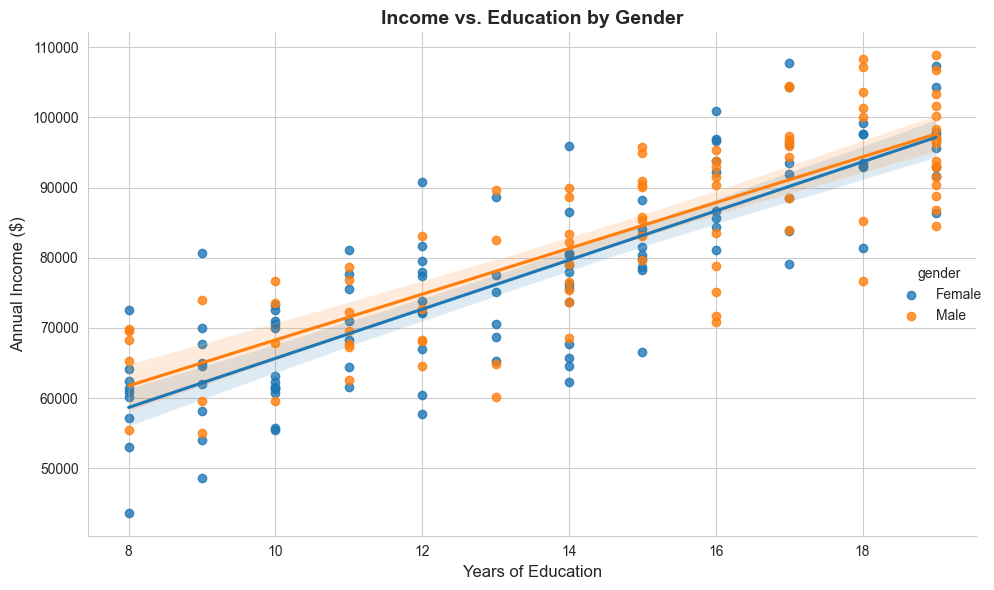

Figure generated: scatter plot with regression lines and confidence intervals


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Create sample education-income data
np.random.seed(42)
n = 200
edu_data = pd.DataFrame({
    "education": np.random.randint(8, 20, n),
    "gender": np.random.choice(["Male", "Female"], n),
})
edu_data["income"] = 30000 + edu_data["education"] * 3500 + np.random.normal(0, 8000, n)

# Scatter plot with regression line and confidence band
plt.figure(figsize=(10, 6))
sns.lmplot(
    x="education", y="income", data=edu_data, hue="gender", ci=95, height=6, aspect=1.5
)
plt.title("Income vs. Education by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Years of Education", fontsize=12)
plt.ylabel("Annual Income ($)", fontsize=12)
plt.tight_layout()
# plt.savefig('figure1.pdf', dpi=300)  # Uncomment to save
plt.show()

print("Figure generated: scatter plot with regression lines and confidence intervals")

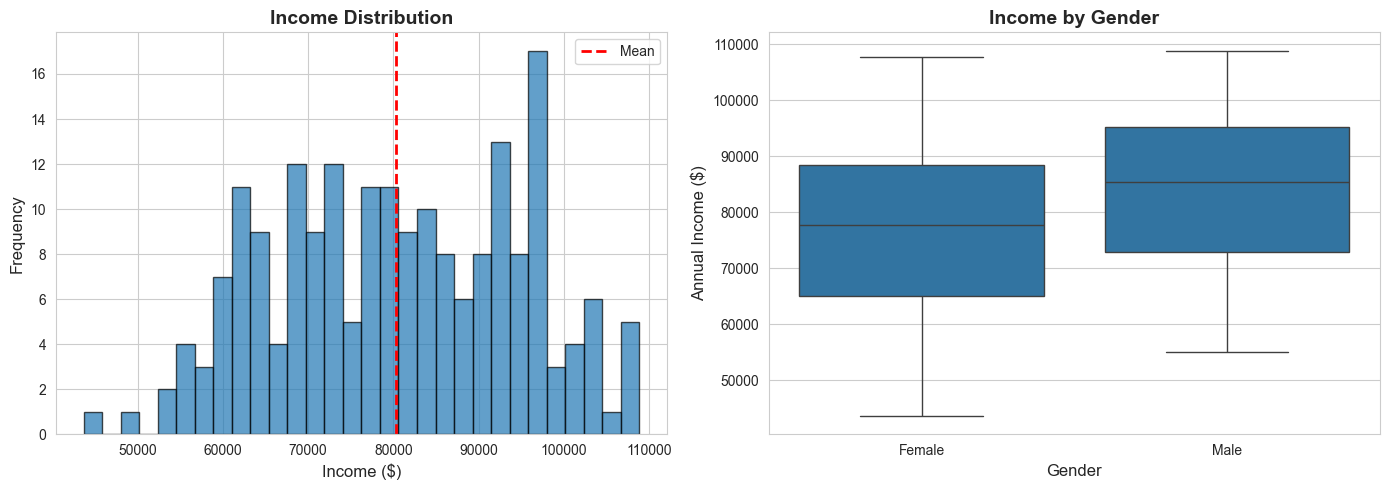

In [9]:
# Additional visualization examples

# 1. Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(edu_data["income"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Income ($)", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_title("Income Distribution", fontsize=14, fontweight="bold")
axes[0].axvline(
    edu_data["income"].mean(), color="red", linestyle="--", linewidth=2, label="Mean"
)
axes[0].legend()

# 2. Box plot by gender
sns.boxplot(x="gender", y="income", data=edu_data, ax=axes[1])
axes[1].set_ylabel("Annual Income ($)", fontsize=12)
axes[1].set_xlabel("Gender", fontsize=12)
axes[1].set_title("Income by Gender", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## Interactive Visualization

Static plots are great for papers, but **interactive charts** are powerful for exploration and presentations.

In [28]:
import plotly.express as px

# Create animated scatter plot (Hans Rosling style)
# Using gapminder-like data
np.random.seed(42)
years = list(range(1990, 2021))
countries = ["USA", "China", "India", "Brazil", "Germany", "Japan"]
continents = {
    "USA": "Americas",
    "China": "Asia",
    "India": "Asia",
    "Brazil": "Americas",
    "Germany": "Europe",
    "Japan": "Asia",
}

gap_data = []
for country in countries:
    base_gdp = np.random.randint(5000, 30000)
    base_life = np.random.randint(65, 75)
    base_pop = np.random.randint(50, 1300)

    for i, year in enumerate(years):
        gap_data.append({
            "country": country,
            "year": year,
            "continent": continents[country],
            "gdpPercap": base_gdp * (1.02**i) + np.random.randint(-1000, 1000),
            "lifeExp": base_life + i * 0.2 + np.random.uniform(-0.5, 0.5),
            "pop": base_pop * (1.01**i) * 1e6,
        })

gapminder = pd.DataFrame(gap_data)

# Create animated scatter plot
fig = px.scatter(
    gapminder,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    animation_frame="year",
    hover_name="country",
    log_x=True,
    size_max=60,
    range_x=[3000, 60000],
    range_y=[60, 85],
    title="GDP per Capita vs. Life Expectancy Over Time",
    labels={"gdpPercap": "GDP per Capita ($)", "lifeExp": "Life Expectancy (years)"},
)

fig.update_layout(height=600)
fig.show()

print("Interactive plot: Hover over points, use the timeline slider to animate!")

Interactive plot: Hover over points, use the timeline slider to animate!


---
# Part IV: Econometrics in Python

## Regression Analysis

Python supports the full toolkit of regression analysis that social scientists rely on, with syntax that feels familiar if you know Stata or R.

In [29]:
import statsmodels.formula.api as smf

# Create wage data
np.random.seed(42)
n = 500
wage_data = pd.DataFrame({
    "education": np.random.randint(8, 20, n),
    "experience": np.random.randint(0, 40, n),
    "gender": np.random.choice(["Male", "Female"], n),
})

# Generate wage with some true relationship
wage_data["wage"] = (
    10
    + 2.5 * wage_data["education"]
    + 0.5 * wage_data["experience"]
    + 3 * (wage_data["gender"] == "Male")
    + np.random.normal(0, 5, n)
)

# OLS regression with R-style formula
model = smf.ols("wage ~ education + experience + C(gender)", data=wage_data).fit(
    cov_type="HC3"
)  # Robust standard errors

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     866.1
Date:                Mon, 16 Feb 2026   Prob (F-statistic):          1.07e-196
Time:                        12:35:51   Log-Likelihood:                -1504.3
No. Observations:                 500   AIC:                             3017.
Df Residuals:                     496   BIC:                             3034.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             9.6500      0.92

In [12]:
# Extract key results
print("\nKey Results:")
print(f"Education coefficient: {model.params['education']:.3f}")
print(f"Education p-value: {model.pvalues['education']:.4f}")
print(f"R-squared: {model.rsquared:.3f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.3f}")

# Get confidence intervals
print("\nConfidence Intervals (95%):")
print(model.conf_int())


Key Results:
Education coefficient: 2.580
Education p-value: 0.0000
R-squared: 0.832
Adjusted R-squared: 0.831

Confidence Intervals (95%):
                          0          1
Intercept          7.829717  11.470371
C(gender)[T.Male]  2.227223   3.950538
education          2.460359   2.699270
experience         0.453868   0.527897


## Panel Data & Fixed Effects

Fixed effects models are the workhorse of applied microeconomics — control for all time-invariant unobserved heterogeneity.

$$y_{it} = \beta x_{it} + \alpha_i + \delta_t + \epsilon_{it}$$

In [13]:
try:
    import pyfixest as pf

    # Create panel data for fixed effects
    np.random.seed(42)
    workers = range(1, 101)
    years = range(2015, 2022)

    panel_fe = []
    for worker in workers:
        worker_ability = np.random.normal(0, 5)
        for year in years:
            year_shock = np.random.normal(0, 2)
            education = np.random.randint(12, 18)
            wage = (
                50
                + worker_ability  # Worker fixed effect
                + year_shock  # Year fixed effect
                + 3 * education
                + np.random.normal(0, 3)
            )
            panel_fe.append({
                "worker": worker,
                "year": year,
                "wage": wage,
                "education": education,
            })

    panel_fe = pd.DataFrame(panel_fe)

    # Two-way fixed effects regression
    mod = pf.feols(
        "wage ~ education | worker + year",
        data=panel_fe,
        vcov={"CRV1": "worker"},  # Cluster standard errors by worker
    )

    print("Fixed Effects Regression Results:")
    mod.summary()

except ImportError:
    print("pyfixest not installed. Install with: pip install pyfixest")
    print("\nAlternatively, we can use statsmodels with demeaning:")

    # Manual fixed effects using demeaning
    panel_fe["wage_demean"] = panel_fe.groupby("worker")["wage"].transform(
        lambda x: x - x.mean()
    )
    panel_fe["education_demean"] = panel_fe.groupby("worker")["education"].transform(
        lambda x: x - x.mean()
    )

    # Within estimator
    fe_model = smf.ols("wage_demean ~ education_demean - 1", data=panel_fe).fit()
    print("\nFixed Effects (manual demeaning):")
    print(fe_model.summary())

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Fixed Effects Regression Results:
###

Estimation:  OLS
Dep. var.: wage, Fixed effects: worker+year
Inference:  CRV1
Observations:  700

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| education     |      3.104 |        0.086 |    35.913 |      0.000 |  2.933 |   3.276 |
---
RMSE: 3.323 R2: 0.829 R2 Within: 0.683 


## Difference-in-Differences

**The idea:** Compare the change in outcomes for a treated group to the change for a control group. The key assumption is that both groups would have followed **parallel trends** without treatment.

$$y_{it} = \beta_0 + \beta_1 \text{Treat}_i + \beta_2 \text{Post}_t + \beta_3 (\text{Treat}_i \times \text{Post}_t) + \epsilon_{it}$$

$\beta_3$ is the **treatment effect** — the causal impact of the policy.

In [14]:
# Create DiD data
np.random.seed(42)
units = 200
periods = 10

did_data = []
for unit in range(1, units + 1):
    treated = unit > units / 2  # Half treated, half control
    unit_effect = np.random.normal(50, 10)

    for t in range(1, periods + 1):
        post = t > periods / 2
        time_trend = t * 0.5

        # Treatment effect of 10 for treated units after period 5
        treatment_effect = 10 if (treated and post) else 0

        outcome = unit_effect + time_trend + treatment_effect + np.random.normal(0, 5)

        did_data.append({
            "unit": unit,
            "period": t,
            "treated": int(treated),
            "post": int(post),
            "outcome": outcome,
        })

did_df = pd.DataFrame(did_data)
did_df["treat_x_post"] = did_df["treated"] * did_df["post"]

# Estimate DiD
did_model = smf.ols("outcome ~ treated + post + treat_x_post", data=did_df).fit(
    cov_type="cluster", cov_kwds={"groups": did_df["unit"]}
)

print("Difference-in-Differences Results:")
print(did_model.summary())

print(f"\nEstimated Treatment Effect: {did_model.params['treat_x_post']:.3f}")
print(f"True Treatment Effect: 10.000")
print(f"P-value: {did_model.pvalues['treat_x_post']:.4f}")

Difference-in-Differences Results:
                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     590.4
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           9.20e-99
Time:                        09:29:29   Log-Likelihood:                -7756.3
No. Observations:                2000   AIC:                         1.552e+04
Df Residuals:                    1996   BIC:                         1.554e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    

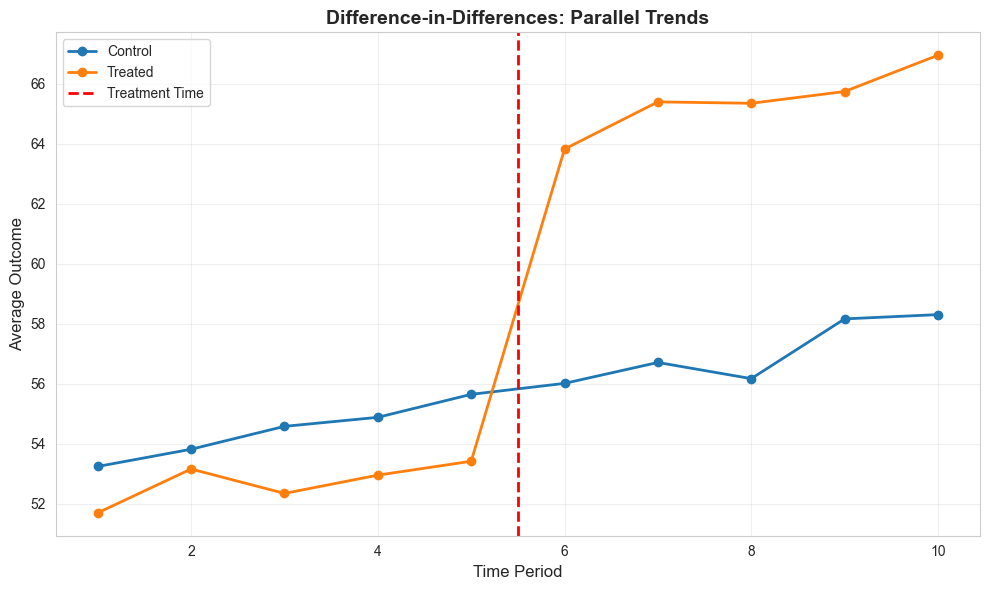

In [15]:
# Visualize parallel trends
did_avg = did_df.groupby(["period", "treated"])["outcome"].mean().reset_index()

plt.figure(figsize=(10, 6))
for treat in [0, 1]:
    data = did_avg[did_avg["treated"] == treat]
    label = "Treated" if treat == 1 else "Control"
    plt.plot(data["period"], data["outcome"], marker="o", linewidth=2, label=label)

plt.axvline(x=5.5, color="red", linestyle="--", linewidth=2, label="Treatment Time")
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Average Outcome", fontsize=12)
plt.title("Difference-in-Differences: Parallel Trends", fontsize=14, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Simulation & Bootstrap

### Monte Carlo Simulation
Generate data where you **know the truth**, then test whether your estimator recovers it.

In [31]:
# Monte Carlo simulation for power analysis
def simulate_once(n=100, true_effect=2.0, noise_sd=5.0):
    """Simulate one dataset and test if we reject H0: beta = 0"""
    x = np.random.normal(0, 1, n)
    y = true_effect * x + np.random.normal(0, noise_sd, n)

    data = pd.DataFrame({"x": x, "y": y})
    model = smf.ols("y ~ x", data=data).fit()

    # Reject at 5% level?
    return model.pvalues["x"] < 0.05


# Run 1000 simulations
n_sims = 1000
results = [simulate_once() for _ in range(n_sims)]
power = np.mean(results)

print(f"Monte Carlo Simulation Results (n=100, true effect=2.0):")
print(f"Number of simulations: {n_sims}")
print(f"Rejections at 5% level: {sum(results)}")
print(f"Statistical Power: {power:.3f}")
print(f"\nInterpretation: We have {power * 100:.1f}% power to detect this effect")

Monte Carlo Simulation Results (n=100, true effect=2.0):
Number of simulations: 1000
Rejections at 5% level: 968
Statistical Power: 0.968

Interpretation: We have 96.8% power to detect this effect


Bootstrap Inference Results:
Sample median: 6.24
Bootstrap SE: 1.15
95% CI: [3.98, 8.40]


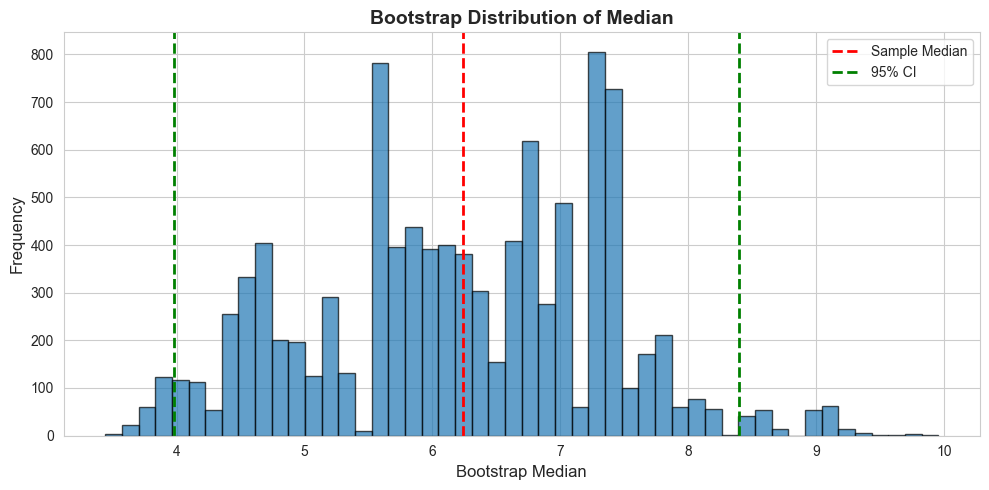

In [17]:
# Bootstrap inference example
from scipy import stats

# Original sample
np.random.seed(42)
sample = np.random.exponential(scale=10, size=100)  # Skewed distribution

# Bootstrap the median
n_bootstrap = 10000
bootstrap_medians = []

for _ in range(n_bootstrap):
    resample = np.random.choice(sample, size=len(sample), replace=True)
    bootstrap_medians.append(np.median(resample))

bootstrap_medians = np.array(bootstrap_medians)

# Calculate confidence interval
ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)

print("Bootstrap Inference Results:")
print(f"Sample median: {np.median(sample):.2f}")
print(f"Bootstrap SE: {np.std(bootstrap_medians):.2f}")
print(f"95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")

# Visualize bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_medians, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(
    np.median(sample), color="red", linestyle="--", linewidth=2, label="Sample Median"
)
plt.axvline(ci_lower, color="green", linestyle="--", linewidth=2, label="95% CI")
plt.axvline(ci_upper, color="green", linestyle="--", linewidth=2)
plt.xlabel("Bootstrap Median", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Bootstrap Distribution of Median", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

---
# Part V: Machine Learning & AI

## What Machine Learning Offers Social Scientists

### Prediction
- Which students are at risk of dropping out?
- What will unemployment be next quarter?
- Where should we target inspections?

ML excels at finding complex patterns in data, even when you don't know the functional form in advance.

### Strengthening Causal Inference
- **Variable selection** — which controls matter among hundreds of candidates?
- **Heterogeneity** — who benefits most from a policy?

ML is not a substitute for identification — it is a *tool that strengthens it.*

## The ML Workflow

The key discipline of machine learning: **never evaluate a model on the data it was trained on.**

1. **Split** the data into training and test sets
2. **Train** the model on the training set
3. **Evaluate** on the held-out test set
4. **Cross-validate** to tune hyperparameters

This prevents **overfitting** — the model learning noise rather than signal.

In [32]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LassoCV, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create high-dimensional data with sparse true model
np.random.seed(42)
n = 500
p = 50  # 50 potential predictors

X = np.random.normal(0, 1, (n, p))
# True model: only first 5 variables matter
true_coefs = np.zeros(p)
true_coefs[:5] = [3, -2, 1.5, -1, 2.5]
y = X @ true_coefs + np.random.normal(0, 2, n)

# Create DataFrame
ml_data = pd.DataFrame(X, columns=[f"X{i}" for i in range(1, p + 1)])
ml_data["y"] = y

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    ml_data.drop("y", axis=1), ml_data["y"], test_size=0.2, random_state=42
)

# LASSO with cross-validation for automatic variable selection
lasso = LassoCV(cv=5, random_state=42).fit(X_train, y_train)

# Predictions
y_pred_train = lasso.predict(X_train)
y_pred_test = lasso.predict(X_test)

print("Machine Learning Results (LASSO):")
print(f"\nTraining R²: {r2_score(y_train, y_pred_train):.3f}")
print(f"Test R²: {r2_score(y_test, y_pred_test):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")

# Variable selection
selected_vars = np.where(lasso.coef_ != 0)[0]
print(f"\nVariables selected by LASSO: {len(selected_vars)} out of {p}")
print(f"True important variables: 5 (X1-X5)")

# Show coefficients of important variables
important_coefs = pd.DataFrame({
    "Variable": [f"X{i + 1}" for i in selected_vars],
    "Coefficient": lasso.coef_[selected_vars],
}).sort_values("Coefficient", key=abs, ascending=False)

print("\nEstimated Coefficients (non-zero):")
print(important_coefs)

Machine Learning Results (LASSO):

Training R²: 0.858
Test R²: 0.853
Test RMSE: 1.950

Variables selected by LASSO: 11 out of 50
True important variables: 5 (X1-X5)

Estimated Coefficients (non-zero):
   Variable  Coefficient
0        X1     2.823162
4        X5     2.280752
1        X2    -1.897491
2        X3     1.358517
3        X4    -0.973910
7       X20    -0.115043
9       X29    -0.072261
10      X36    -0.059314
8       X25     0.033409
5        X9    -0.026773
6       X17    -0.010789


In [19]:
# Compare different ML methods
from sklearn.linear_model import LinearRegression

models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "LASSO": LassoCV(cv=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_score = r2_score(y_train, model.predict(X_train))
    test_score = r2_score(y_test, model.predict(X_test))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))

    results.append({
        "Model": name,
        "Train R²": train_score,
        "Test R²": test_score,
        "Test RMSE": test_rmse,
        "Overfit": train_score - test_score,
    })

comparison = pd.DataFrame(results)
print("\nModel Comparison:")
print(comparison.to_string(index=False))

print("\nNote: LASSO and Ridge prevent overfitting better than OLS in high dimensions")


Model Comparison:
        Model  Train R²  Test R²  Test RMSE  Overfit
          OLS  0.874313 0.855346   1.937470 0.018967
        Ridge  0.874307 0.855238   1.938193 0.019069
        LASSO  0.857757 0.853468   1.950004 0.004288
Random Forest  0.952127 0.598969   3.225959 0.353158

Note: LASSO and Ridge prevent overfitting better than OLS in high dimensions


## Causal Machine Learning: Double ML

**The problem:** You want the causal effect of $D$ on $Y$, but you have hundreds of potential confounders $X$. Which controls should you include?

**Double ML** (Chernozhukov et al., 2018):
1. Use ML to predict $Y$ from $X$ (flexibly)
2. Use ML to predict $D$ from $X$ (flexibly)
3. Regress the *residuals* of $Y$ on the *residuals* of $D$
4. The coefficient is the **causal effect** of $D$

No need to choose a parametric specification for the confounders. ML handles the "nuisance" so you can focus on the causal question.

In [20]:
# Double ML simulation
np.random.seed(42)
n = 1000
p = 20

# Generate confounders
X = np.random.normal(0, 1, (n, p))

# Treatment depends on confounders (complex, nonlinear relationship)
D = X[:, 0] + 0.5 * X[:, 1] ** 2 + 0.3 * X[:, 2] * X[:, 3] + np.random.normal(0, 1, n)

# Outcome depends on treatment AND confounders
true_effect = 2.0
Y = (
    true_effect * D  # TRUE CAUSAL EFFECT
    + X[:, 0]
    + 0.5 * X[:, 1] ** 2
    + 0.3 * X[:, 2] * X[:, 3]
    + np.random.normal(0, 1, n)
)

# Naive OLS (biased because ignores confounding)
naive_data = pd.DataFrame({"Y": Y, "D": D})
naive_model = smf.ols("Y ~ D", data=naive_data).fit()

print("Naive OLS (no controls):")
print(f"Estimated effect: {naive_model.params['D']:.3f}")
print(f"True effect: {true_effect:.3f}")
print(f"Bias: {naive_model.params['D'] - true_effect:.3f}")

# Double ML approach
from sklearn.ensemble import RandomForestRegressor

# Step 1: Predict Y from X using ML
ml_y = RandomForestRegressor(n_estimators=100, random_state=42)
ml_y.fit(X, Y)
Y_pred = ml_y.predict(X)
Y_resid = Y - Y_pred

# Step 2: Predict D from X using ML
ml_d = RandomForestRegressor(n_estimators=100, random_state=42)
ml_d.fit(X, D)
D_pred = ml_d.predict(X)
D_resid = D - D_pred

# Step 3: Regress residuals
dml_data = pd.DataFrame({"Y_resid": Y_resid, "D_resid": D_resid})
dml_model = smf.ols("Y_resid ~ D_resid - 1", data=dml_data).fit()

print("\nDouble ML:")
print(f"Estimated effect: {dml_model.params['D_resid']:.3f}")
print(f"True effect: {true_effect:.3f}")
print(f"Bias: {dml_model.params['D_resid'] - true_effect:.3f}")
print(f"\nDouble ML successfully recovers the causal effect!")

Naive OLS (no controls):
Estimated effect: 2.626
True effect: 2.000
Bias: 0.626

Double ML:
Estimated effect: 2.086
True effect: 2.000
Bias: 0.086

Double ML successfully recovers the causal effect!


---
# Part VI: Geospatial Analysis & Satellite Imagery

## Maps & Choropleth Visualization

**Choropleth maps** color geographic regions (states, counties, countries) by a variable — poverty rates, election margins, treatment intensity.

Social scientists use maps to:
- Visualize spatial variation in economic outcomes
- Identify geographic patterns and clusters
- Communicate results to policymakers and the public
- Merge spatial data with administrative records

In [33]:
# Create a choropleth map example using plotly

# Create state-level economic data
state_econ = pd.DataFrame({
    "state": [
        "California",
        "Texas",
        "Florida",
        "New York",
        "Pennsylvania",
        "Illinois",
        "Ohio",
        "Georgia",
        "North Carolina",
        "Michigan",
    ],
    "state_code": ["CA", "TX", "FL", "NY", "PA", "IL", "OH", "GA", "NC", "MI"],
    "median_income": [
        75235,
        61874,
        55660,
        72108,
        61744,
        65030,
        58642,
        58756,
        54602,
        59584,
    ],
    "unemployment_rate": [4.2, 3.9, 3.4, 4.5, 4.6, 4.4, 4.1, 3.5, 3.6, 4.0],
    "gini_coefficient": [
        0.489,
        0.477,
        0.481,
        0.514,
        0.461,
        0.481,
        0.461,
        0.485,
        0.468,
        0.471,
    ],
})

# Create choropleth map
fig = px.choropleth(
    state_econ,
    locations="state_code",
    locationmode="USA-states",
    color="median_income",
    hover_name="state",
    hover_data={
        "state_code": False,
        "median_income": ":$,.0f",
        "unemployment_rate": ":.1f%",
        "gini_coefficient": ":.3f",
    },
    color_continuous_scale="Viridis",
    scope="usa",
    title="Median Household Income by State",
    labels={"median_income": "Median Income ($)"},
)

fig.update_layout(height=500, margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

print("Interactive choropleth map created!")
print("Hover over states to see details, zoom and pan to explore.")

Interactive choropleth map created!
Hover over states to see details, zoom and pan to explore.


## Google Earth Engine: Satellite Data for Social Science

**Google Earth Engine** provides access to petabytes of satellite imagery and geospatial datasets — all accessible from Python.

### Why Social Scientists Use Satellite Data

When official statistics are unavailable, unreliable, or measured at the wrong geographic scale, satellite imagery offers an alternative:

- **Nighttime lights** → proxy for economic activity, development, inequality
- **Vegetation indices (NDVI)** → agricultural productivity, food security, climate impacts
- **Land cover change** → deforestation, urbanization, infrastructure development
- **Surface temperature** → climate adaptation, urban heat islands
- **Precipitation & drought** → agricultural shocks, migration, conflict

### Applications in Economics

1. **Measuring economic growth** where GDP data is unreliable (Henderson et al., 2012)
2. **Tracking poverty** at fine geographic scales using machine learning on satellite images
3. **Environmental policy evaluation** — did protected areas reduce deforestation?
4. **Conflict research** — agricultural shocks and civil war
5. **Urban economics** — measuring sprawl, informal settlements, infrastructure

/Users/lordflaron/Documents/ec34-ds-for-econ/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning:

You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.



✓ Google Earth Engine initialized successfully!

Example 1: Nighttime Lights for New York City Area
------------------------------------------------------------
Average nighttime light radiance (2020): 26.18
→ Higher values indicate more economic activity/electrification

Example 2: Vegetation Index (NDVI) - Agricultural Productivity
------------------------------------------------------------
Average NDVI (summer 2021): 0.345
→ Range: -1 to 1, higher = more vegetation/productivity

Example 3: Time Series - Nighttime Lights Over Time
------------------------------------------------------------
 year  avg_radiance
 2018     25.123482
 2019     26.170102
 2020     26.182105
 2021     28.738604
 2022     29.882252



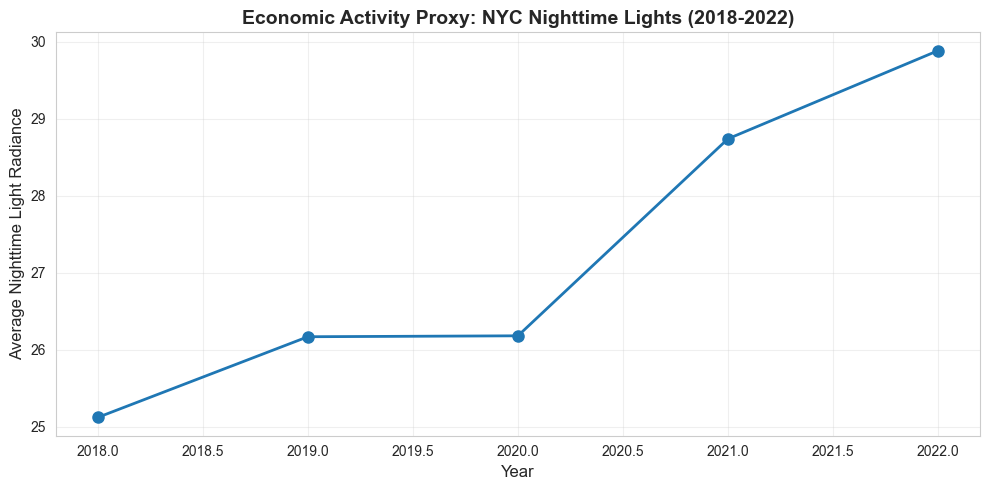


Research Workflow:
1. Define regions of interest (cities, countries, treatment areas)
2. Extract satellite metrics over time
3. Merge with administrative/survey data
4. Run econometric analysis (DiD, RDD, panel FE, etc.)


In [22]:
# Google Earth Engine Example
# Note: Requires ee package and authentication
# Install: pip install earthengine-api
# Authenticate once: earthengine authenticate


import ee

# Initialize Earth Engine
# If this fails, run: earthengine authenticate
ee.Authenticate()
ee.Initialize()

print("✓ Google Earth Engine initialized successfully!")
print("=" * 60)
print()

# Example 1: Extract nighttime lights data for economic analysis
print("Example 1: Nighttime Lights for New York City Area")
print("-" * 60)

# Define a region of interest (New York City area)
roi = ee.Geometry.Rectangle([-74.5, 40.4, -73.7, 40.9])

# Load VIIRS Nighttime Lights dataset
# This is often used as a proxy for economic activity
nightlights = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG")

# Filter to 2020
lights_2020 = nightlights.filterDate("2020-01-01", "2020-12-31")

# Calculate mean nighttime lights for 2020
mean_lights = lights_2020.select("avg_rad").mean()

# Get statistics for the region
stats = mean_lights.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi,
    scale=1000,  # 1km resolution
)

# Get the result
result = stats.getInfo()
avg_radiance = result["avg_rad"]

print(f"Average nighttime light radiance (2020): {avg_radiance:.2f}")
print("→ Higher values indicate more economic activity/electrification")
print()

# Example 2: Calculate vegetation index (NDVI) for agricultural analysis
print("Example 2: Vegetation Index (NDVI) - Agricultural Productivity")
print("-" * 60)

# Define a rural/agricultural region (example: Central Valley, CA)
ag_region = ee.Geometry.Rectangle([-121.5, 36.5, -119.5, 38.0])

# Load Sentinel-2 imagery
s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")

# Filter to growing season 2021
s2_filtered = s2.filterBounds(ag_region).filterDate("2021-06-01", "2021-08-31")


# Calculate NDVI (Normalized Difference Vegetation Index)
def add_ndvi(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    return image.addBands(ndvi)


s2_ndvi = s2_filtered.map(add_ndvi)

# Get mean NDVI
mean_ndvi = s2_ndvi.select("NDVI").mean()
ndvi_stats = mean_ndvi.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ag_region,
    scale=100,  # 100m resolution
)

ndvi_result = ndvi_stats.getInfo()
avg_ndvi = ndvi_result["NDVI"]

print(f"Average NDVI (summer 2021): {avg_ndvi:.3f}")
print("→ Range: -1 to 1, higher = more vegetation/productivity")
print()

# Example 3: Extract time series data
print("Example 3: Time Series - Nighttime Lights Over Time")
print("-" * 60)

# Get nighttime lights for multiple years
years = [2018, 2019, 2020, 2021, 2022]
lights_data = []

city_roi = ee.Geometry.Rectangle([-74.5, 40.4, -73.7, 40.9])  # NYC

for year in years:
    yearly_lights = nightlights.filterDate(f"{year}-01-01", f"{year}-12-31")
    mean_yearly = yearly_lights.select("avg_rad").mean()
    stats_yearly = mean_yearly.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=city_roi, scale=1000
    )
    value = stats_yearly.getInfo()["avg_rad"]
    lights_data.append({"year": year, "avg_radiance": value})

# Convert to DataFrame
lights_df = pd.DataFrame(lights_data)
print(lights_df.to_string(index=False))
print()

# Visualize time series
plt.figure(figsize=(10, 5))
plt.plot(
    lights_df["year"],
    lights_df["avg_radiance"],
    marker="o",
    linewidth=2,
    markersize=8,
)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Nighttime Light Radiance", fontsize=12)
plt.title(
    "Economic Activity Proxy: NYC Nighttime Lights (2018-2022)",
    fontsize=14,
    fontweight="bold",
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("=" * 60)
print("Research Workflow:")
print("1. Define regions of interest (cities, countries, treatment areas)")
print("2. Extract satellite metrics over time")
print("3. Merge with administrative/survey data")
print("4. Run econometric analysis (DiD, RDD, panel FE, etc.)")
print("=" * 60)


### Research Example: Nighttime Lights and Economic Development

**Paper:** Henderson, Storeygard, and Weil (2012) - "Measuring Economic Growth from Outer Space"

**Key insight:** In countries with poor statistical capacity, nighttime lights from satellites correlate strongly with GDP and can fill in data gaps.

**Typical workflow:**

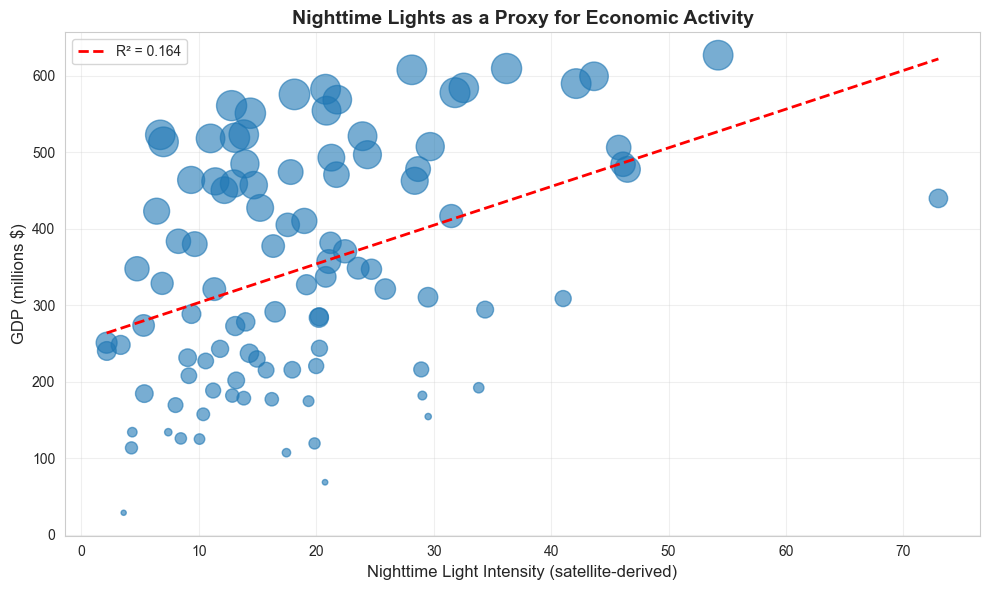

Regression: GDP on Nighttime Lights
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               43.5581      5.811      7.496      0.000      32.169      54.947
nightlight_intensity     2.7619      0.183     15.093      0.000       2.403       3.121
population               0.0010   1.59e-05     63.435      0.000       0.001       0.001

Interpretation: A 1-unit increase in nightlight intensity
is associated with $2.76M in GDP


In [23]:
# Simulated workflow: Nighttime lights and local economic outcomes

# Suppose you've extracted nighttime lights data from Earth Engine for each district
# and you have administrative data on GDP or survey data

# Create example data
np.random.seed(42)
n_districts = 100

satellite_econ = pd.DataFrame({
    "district_id": range(1, n_districts + 1),
    "year": 2020,
    "nightlight_intensity": np.random.gamma(shape=2, scale=10, size=n_districts),
    "population": np.random.randint(10000, 500000, n_districts),
})

# Simulate GDP as a function of nightlights (with noise)
satellite_econ["gdp_millions"] = (
    50
    + 2.5 * satellite_econ["nightlight_intensity"]
    + 0.001 * satellite_econ["population"]
    + np.random.normal(0, 20, n_districts)
)

# Visualize relationship between nighttime lights and economic activity
plt.figure(figsize=(10, 6))
plt.scatter(
    satellite_econ["nightlight_intensity"],
    satellite_econ["gdp_millions"],
    alpha=0.6,
    s=satellite_econ["population"] / 1000,
)

# Add regression line
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(
    satellite_econ["nightlight_intensity"], satellite_econ["gdp_millions"]
)
x_line = np.linspace(
    satellite_econ["nightlight_intensity"].min(),
    satellite_econ["nightlight_intensity"].max(),
    100,
)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, "r--", linewidth=2, label=f"R² = {r_value**2:.3f}")

plt.xlabel("Nighttime Light Intensity (satellite-derived)", fontsize=12)
plt.ylabel("GDP (millions $)", fontsize=12)
plt.title(
    "Nighttime Lights as a Proxy for Economic Activity", fontsize=14, fontweight="bold"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Run regression
model_sat = smf.ols(
    "gdp_millions ~ nightlight_intensity + population", data=satellite_econ
).fit(cov_type="HC3")

print("Regression: GDP on Nighttime Lights")
print("=" * 50)
print(model_sat.summary().tables[1])
print(f"\nInterpretation: A 1-unit increase in nightlight intensity")
print(f"is associated with ${model_sat.params['nightlight_intensity']:.2f}M in GDP")

---
# Part VII: Computer Vision for Social Science

## Images as Data

Many historical and contemporary sources exist as **images** rather than structured data:
- Scanned census records, tax documents, newspapers
- Historical maps and photographs
- Satellite/aerial imagery of cities, farms, infrastructure
- Social media images, product photos, advertisements

Computer vision lets us turn images into analyzable data at scale.

### Applications in Social Science

1. **Historical digitization** — extract structured data from scanned archives
2. **Land use classification** — identify building types, informal settlements, agricultural practices
3. **Infrastructure measurement** — count roads, electricity access, vehicle ownership from aerial imagery
4. **Consumption & wealth prediction** — estimate household wealth from satellite images of roof materials
5. **Content analysis** — classify images from social media, advertisements, news

## Optical Character Recognition (OCR)

**OCR** extracts text from images — essential for digitizing historical records.

**Use cases:**
- Census records (names, ages, occupations)
- Birth/death certificates
- Historical newspapers
- Tax records and ledgers
- Court documents and legislative records

In [24]:
# OCR Example with pytesseract
# Install: pip install pytesseract pillow
# Also requires Tesseract OCR engine

print("Optical Character Recognition (OCR)")
print("=" * 60)
print()
print("OCR extracts text from scanned documents and images.")
print()
print("To use OCR in Python:")
print("1. Install Tesseract: https://github.com/tesseract-ocr/tesseract")
print("2. Install Python wrapper: pip install pytesseract pillow")
print()
print("Example workflow:")
print()
print("```python")
print("from PIL import Image")
print("import pytesseract")
print()
print("# Load scanned document")
print("img = Image.open('census_record_1920.png')")
print()
print("# Extract text")
print("text = pytesseract.image_to_string(img)")
print()
print("# Parse structured data")
print("import re")
print("name = re.search(r'Name:\\s*(.+)', text).group(1)")
print("age = int(re.search(r'Age:\\s*(\\d+)', text).group(1))")
print("occupation = re.search(r'Occupation:\\s*(.+)', text).group(1)")
print("```")
print()
print("=" * 60)
print()
print("Real-world applications:")
print("- Digitize thousands of historical census pages")
print("- Extract data from scanned newspapers for text analysis")
print("- Process handwritten documents (with specialized models)")
print("- Build datasets from archival sources automatically")
print()
print("Impact: Projects that would take years manually")
print("        can be completed in weeks with OCR + Python")

Optical Character Recognition (OCR)

OCR extracts text from scanned documents and images.

To use OCR in Python:
1. Install Tesseract: https://github.com/tesseract-ocr/tesseract
2. Install Python wrapper: pip install pytesseract pillow

Example workflow:

```python
from PIL import Image
import pytesseract

# Load scanned document
img = Image.open('census_record_1920.png')

# Extract text
text = pytesseract.image_to_string(img)

# Parse structured data
import re
name = re.search(r'Name:\s*(.+)', text).group(1)
age = int(re.search(r'Age:\s*(\d+)', text).group(1))
occupation = re.search(r'Occupation:\s*(.+)', text).group(1)
```


Real-world applications:
- Digitize thousands of historical census pages
- Extract data from scanned newspapers for text analysis
- Process handwritten documents (with specialized models)
- Build datasets from archival sources automatically

Impact: Projects that would take years manually
        can be completed in weeks with OCR + Python


## Image Classification: Predicting Poverty from Satellite Images

**Breakthrough paper:** Jean et al. (2016) - "Combining satellite imagery and machine learning to predict poverty"

**The idea:**
1. Survey data on household wealth is expensive and rare
2. Satellite images are freely available everywhere
3. Train a neural network to predict wealth from images (roof materials, roads, vegetation)
4. Generate poverty estimates for areas without surveys

**Impact:** Enables poverty targeting, resource allocation, and research in data-poor settings

Poverty Prediction from Satellite Features

Classification Report:
              precision    recall  f1-score   support

    Non-Poor       0.86      0.80      0.83        84
        Poor       0.76      0.83      0.80        66

    accuracy                           0.81       150
   macro avg       0.81      0.82      0.81       150
weighted avg       0.82      0.81      0.81       150


Feature Importance:
             Feature  Importance
nightlight_intensity    0.596582
        road_density    0.122688
avg_roof_reflectance    0.107645
    vegetation_index    0.087698
    building_density    0.085388


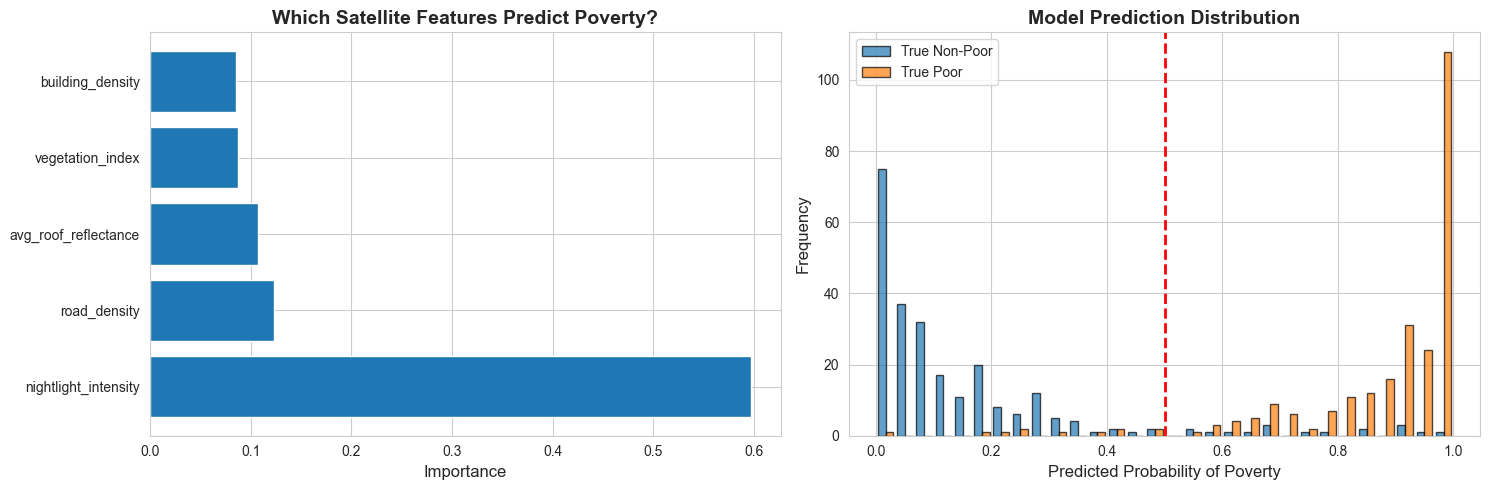


Spatial Distribution of Predicted Poverty


/var/folders/22/d2d1hrtn3kl9cq0gsx95c6lr0000gn/T/ipykernel_86009/3506943981.py:122: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/




📍 Interactive Map Features:
- Red = Predicted Poor villages
- Green = Predicted Non-Poor villages
- Size = Prediction confidence (larger = more confident)
- Hover over points to see satellite features

Policy Application:
1. Use this model to identify poor villages without survey data
2. Target resources, interventions, or research to high-need areas
3. Monitor changes over time as new satellite imagery becomes available
4. Cost: ~$0 for satellite data vs $100-500 per village for surveys


In [25]:
# Simplified example: Image-based prediction with spatial visualization
# In practice, you'd use actual satellite imagery and deep learning (CNNs)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Simulate satellite-derived features for villages
# (In reality, these would be extracted from satellite images using CNNs)
np.random.seed(42)
n_villages = 500

# Create villages with realistic geographic coordinates
# Simulating a region in Sub-Saharan Africa
base_lat, base_lon = -1.5, 30.0  # Around Rwanda/Uganda region
poverty_data = pd.DataFrame({
    "village_id": range(1, n_villages + 1),
    "latitude": base_lat + np.random.uniform(-2, 2, n_villages),
    "longitude": base_lon + np.random.uniform(-2, 2, n_villages),
    # Simulated image features
    "avg_roof_reflectance": np.random.uniform(
        0.1, 0.8, n_villages
    ),  # Metal roofs = high
    "vegetation_index": np.random.uniform(0.2, 0.9, n_villages),  # NDVI
    "road_density": np.random.uniform(0, 1, n_villages),  # Roads per km²
    "nightlight_intensity": np.random.gamma(2, 5, n_villages),
    "building_density": np.random.uniform(0.1, 0.9, n_villages),
})

# Simulate poverty status based on features
# Poor villages: low roof quality, low road density, low nightlights
poverty_score = (
    -2 * poverty_data["avg_roof_reflectance"]
    + -1.5 * poverty_data["road_density"]
    + -0.3 * poverty_data["nightlight_intensity"]
    + np.random.normal(0, 1, n_villages)
)

poverty_data["poor"] = (poverty_score > poverty_score.median()).astype(int)
poverty_data["poverty_label"] = poverty_data["poor"].map({0: "Non-Poor", 1: "Poor"})

# Split into training and test
features = [
    "avg_roof_reflectance",
    "vegetation_index",
    "road_density",
    "nightlight_intensity",
    "building_density",
]

X = poverty_data[features]
y = poverty_data["poor"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train a classifier (in reality, would use a CNN on raw images)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict on ALL villages (for mapping)
poverty_data["predicted_poor"] = clf.predict(X)
poverty_data["predicted_label"] = poverty_data["predicted_poor"].map({
    0: "Non-Poor",
    1: "Poor",
})
poverty_data["prediction_probability"] = clf.predict_proba(X)[:, 1]

# Evaluate on test set
y_pred = clf.predict(X_test)

print("Poverty Prediction from Satellite Features")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Poor", "Poor"]))

# Feature importance
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": clf.feature_importances_,
}).sort_values("Importance", ascending=False)

print("\nFeature Importance:")
print(importance_df.to_string(index=False))

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Feature importance bar chart
axes[0].barh(importance_df["Feature"], importance_df["Importance"])
axes[0].set_xlabel("Importance", fontsize=12)
axes[0].set_title(
    "Which Satellite Features Predict Poverty?", fontsize=14, fontweight="bold"
)

# Prediction probability distribution
axes[1].hist(
    [
        poverty_data[poverty_data["poor"] == 0]["prediction_probability"],
        poverty_data[poverty_data["poor"] == 1]["prediction_probability"],
    ],
    bins=30,
    label=["True Non-Poor", "True Poor"],
    alpha=0.7,
    edgecolor="black",
)
axes[1].set_xlabel("Predicted Probability of Poverty", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].set_title("Model Prediction Distribution", fontsize=14, fontweight="bold")
axes[1].legend()
axes[1].axvline(0.5, color="red", linestyle="--", linewidth=2, label="Threshold")

plt.tight_layout()
plt.show()

# Create interactive map of predictions
print("\n" + "=" * 50)
print("Spatial Distribution of Predicted Poverty")
print("=" * 50)

# Create map with plotly
fig_map = px.scatter_mapbox(
    poverty_data,
    lat="latitude",
    lon="longitude",
    color="predicted_label",
    hover_data={
        "village_id": True,
        "latitude": ":.3f",
        "longitude": ":.3f",
        "prediction_probability": ":.2f",
        "avg_roof_reflectance": ":.2f",
        "road_density": ":.2f",
        "nightlight_intensity": ":.1f",
        "predicted_label": True,
    },
    color_discrete_map={"Poor": "red", "Non-Poor": "green"},
    title="Predicted Poverty Map: 500 Villages from Satellite Imagery",
    zoom=6,
    height=600,
    size="prediction_probability",
    size_max=15,
)

fig_map.update_layout(
    mapbox_style="open-street-map", margin={"r": 0, "t": 40, "l": 0, "b": 0}
)

fig_map.show()

print("\n📍 Interactive Map Features:")
print("- Red = Predicted Poor villages")
print("- Green = Predicted Non-Poor villages")
print("- Size = Prediction confidence (larger = more confident)")
print("- Hover over points to see satellite features")

print("\nPolicy Application:")
print("1. Use this model to identify poor villages without survey data")
print("2. Target resources, interventions, or research to high-need areas")
print("3. Monitor changes over time as new satellite imagery becomes available")
print("4. Cost: ~$0 for satellite data vs $100-500 per village for surveys")

## Deep Learning for Images: Transfer Learning

**The challenge:** Training a neural network from scratch requires millions of images.

**The solution:** **Transfer learning** — use a model pre-trained on millions of images (ImageNet), then fine-tune it for your specific task.

**Social science applications:**
- Classify land use from aerial imagery
- Detect informal housing or slums
- Identify crop types for agricultural economics
- Analyze visual content in media or advertising
- Measure infrastructure quality (roads, buildings)

Training samples: 400
Test samples: 100

Logistic Regression Accuracy: 1.000
Neural Network Accuracy: 0.950


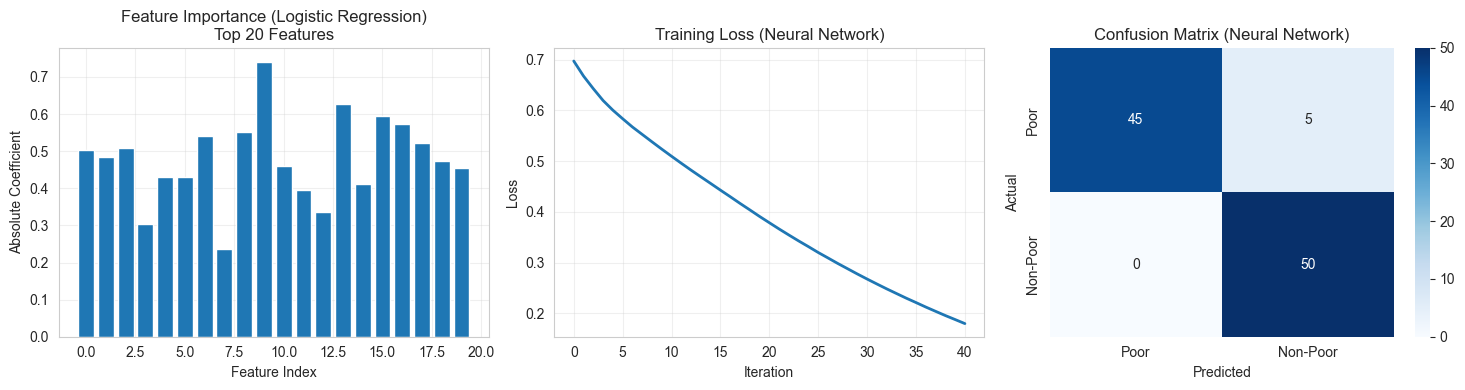


KEY INSIGHTS: Transfer Learning for Social Science
1. Pre-trained features: Instead of training a CNN from scratch,
   use features from models trained on millions of images
2. Feature extraction: Satellite images → CNN features → Predictions
3. Fast training: Only train classifier, not entire network
4. Small data: Works well even with limited labeled examples
5. Applications: Poverty mapping, infrastructure detection,
   land use classification, disaster response, etc.


In [26]:
# Fast Transfer Learning Example: Lightweight CNN for Satellite Images
# This example demonstrates transfer learning concepts without the overhead of downloading large models

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Generate synthetic satellite image data (simplified features instead of full images)
# In practice, these would be extracted from real satellite imagery
np.random.seed(42)
n_samples = 500
img_features = 64  # Simulating 64 pre-extracted features from a convolutional layer

# Simulate "pre-trained features" - as if extracted from a CNN trained on ImageNet
# Poor villages: darker imagery, less vegetation
X_poor = np.random.randn(n_samples // 2, img_features) * 0.5 + np.array(
    [0.3] * 32 + [0.2] * 32
)
# Non-poor villages: brighter imagery, more vegetation
X_nonpoor = np.random.randn(n_samples // 2, img_features) * 0.5 + np.array(
    [0.7] * 32 + [0.6] * 32
)

X = np.vstack([X_poor, X_nonpoor])
y = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2))  # 0=poor, 1=non-poor

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Simple "Transfer Learning" approach: use pre-extracted features with a simple classifier
# This mimics freezing the convolutional layers and training only the final classifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Option 1: Logistic Regression on "frozen features" (fastest)
lr_model = LogisticRegression(random_state=42, max_iter=200)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_score = lr_model.score(X_test, y_test)

print(f"\nLogistic Regression Accuracy: {lr_score:.3f}")

# Option 2: Small neural network (mimics fine-tuning last few layers)
nn_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)
nn_model.fit(X_train, y_train)
nn_pred = nn_model.predict(X_test)
nn_score = nn_model.score(X_test, y_test)

print(f"Neural Network Accuracy: {nn_score:.3f}")

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Feature importance (first 20 features)
feature_importance = np.abs(lr_model.coef_[0][:20])
axes[0].bar(range(20), feature_importance)
axes[0].set_xlabel("Feature Index")
axes[0].set_ylabel("Absolute Coefficient")
axes[0].set_title("Feature Importance (Logistic Regression)\nTop 20 Features")
axes[0].grid(alpha=0.3)

# Plot 2: Learning curve (neural network)
axes[1].plot(nn_model.loss_curve_, linewidth=2)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss")
axes[1].set_title("Training Loss (Neural Network)")
axes[1].grid(alpha=0.3)

# Plot 3: Confusion matrix
cm = confusion_matrix(y_test, nn_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[2],
    xticklabels=["Poor", "Non-Poor"],
    yticklabels=["Poor", "Non-Poor"],
)
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_title("Confusion Matrix (Neural Network)")

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("KEY INSIGHTS: Transfer Learning for Social Science")
print("=" * 60)
print("1. Pre-trained features: Instead of training a CNN from scratch,")
print("   use features from models trained on millions of images")
print("2. Feature extraction: Satellite images → CNN features → Predictions")
print("3. Fast training: Only train classifier, not entire network")
print("4. Small data: Works well even with limited labeled examples")
print("5. Applications: Poverty mapping, infrastructure detection,")
print("   land use classification, disaster response, etc.")


## When to Use Computer Vision

### Good Use Cases ✓
- **Data is visual** — land use, infrastructure, historical documents
- **Scale matters** — analyzing thousands/millions of images
- **Traditional data unavailable** — no surveys, censuses, or admin records
- **Spatial variation** — outcomes vary geographically
- **Cost-effective** — satellite images are free/cheap vs. field surveys

### Challenges ⚠
- **Labeled data required** — need ground truth to train models
- **Cloud cover** — satellite images may be obscured (tropics)
- **Temporal resolution** — satellites revisit every 5-16 days
- **Interpretability** — deep learning models are "black boxes"
- **Validation** — ensure predictions match reality

### Best Practice
Combine computer vision with traditional data sources:
- Use surveys for validation and training
- Use satellite data to fill spatial/temporal gaps
- Report model performance metrics clearly
- Be transparent about limitations

---
# Part VIII: Interoperability

## You Don't Have to Abandon Other Tools

Python can work seamlessly with:
- **Stata** (via `pystata`)
- **R** (via `rpy2`)
- **SQL databases** (via `sqlalchemy`, `pandas`)
- **Excel** (via `openpyxl`, `xlsxwriter`)
- **APIs** (via `requests`)

### Example: Reading from various sources

In [24]:
# Reading from various file formats

# CSV (most common)
# df = pd.read_csv('data.csv')

# Excel
# df = pd.read_excel('data.xlsx', sheet_name='Sheet1')

# Stata .dta files
# df = pd.read_stata('data.dta')

# JSON
# df = pd.read_json('data.json')

# From URL
# df = pd.read_csv('https://example.com/data.csv')

# From SQL database
# from sqlalchemy import create_engine
# engine = create_engine('sqlite:///database.db')
# df = pd.read_sql('SELECT * FROM table', engine)

print("Python can read data from:")
print("- CSV, TSV, and other delimited files")
print("- Excel spreadsheets (.xlsx, .xls)")
print("- Stata files (.dta)")
print("- SAS files (.sas7bdat)")
print("- SPSS files (.sav)")
print("- JSON and XML")
print("- SQL databases (PostgreSQL, MySQL, SQLite, etc.)")
print("- Parquet, Feather (for big data)")
print("- APIs and web scraping")
print("- Cloud storage (S3, Google Cloud, Azure)")

Python can read data from:
- CSV, TSV, and other delimited files
- Excel spreadsheets (.xlsx, .xls)
- Stata files (.dta)
- SAS files (.sas7bdat)
- SPSS files (.sav)
- JSON and XML
- SQL databases (PostgreSQL, MySQL, SQLite, etc.)
- Parquet, Feather (for big data)
- APIs and web scraping
- Cloud storage (S3, Google Cloud, Azure)


---
# Conclusion

## Key Takeaways

1. **Python is a complement**, not a replacement — use it alongside Stata and R

2. **Reproducibility** comes from scripted, version-controlled workflows

3. **Data wrangling** at scale — clean, merge, reshape millions of rows

4. **Visualization** from static journal figures to interactive animated maps

5. **Econometrics** in Python is mature — OLS, fixed effects, DiD, RDD, MLE

6. **Machine learning** strengthens causal inference — Double ML, causal forests

7. **New frontiers** — text as data, satellite imagery, LLMs, computer vision

8. **Interoperability** — call Stata and R from within Python

---

> **Python is not about replacing your toolkit — it is about expanding it.**

## Additional Resources

### Documentation
- [pandas documentation](https://pandas.pydata.org/docs/)
- [statsmodels](https://www.statsmodels.org/)
- [scikit-learn](https://scikit-learn.org/)
- [seaborn](https://seaborn.pydata.org/)
- [plotly](https://plotly.com/python/)

### Books
- *Python for Data Analysis* by Wes McKinney
- *Python Data Science Handbook* by Jake VanderPlas
- *Causal Inference for The Brave and True* by Matheus Facure